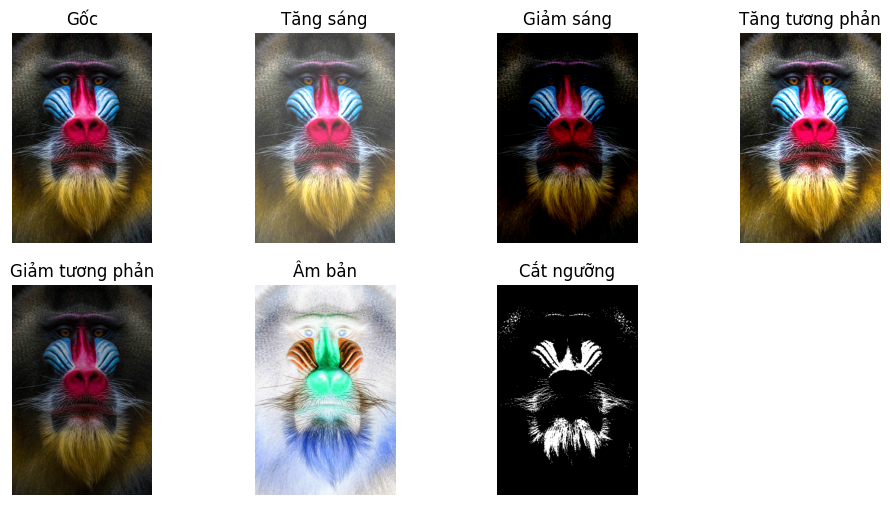

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Đọc ảnh
image = cv2.imread("../input/lab_image.jpg")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# 1. Độ sáng
brightness_value = 60
bright_up = np.clip(image.astype(np.int16) + brightness_value, 0, 255).astype(np.uint8)
bright_down = np.clip(image.astype(np.int16) - brightness_value, 0, 255).astype(np.uint8)

# 2. Tương phản
contrast_factor = 1.5
contrast_img_up = np.clip(image.astype(np.float32) * contrast_factor, 0, 255).astype(np.uint8)
contrast_img_down = np.clip(image.astype(np.float32)   / contrast_factor, 0, 255).astype(np.uint8)

# 3. Âm bản
negative_img = 255 - image

# 4. Threshold
gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
_, thresh_img = cv2.threshold(gray, 128, 255, cv2.THRESH_BINARY)


titles = ['Gốc', 'Tăng sáng', 'Giảm sáng', 'Tăng tương phản', 'Giảm tương phản', 'Âm bản', 'Cắt ngưỡng']
images = [image, bright_up, bright_down, contrast_img_up, contrast_img_down, negative_img, thresh_img]

plt.figure(figsize=(12, 6))

for i in range(len(images)):
    plt.subplot(2, 4, i + 1)
    
    if i == len(images) - 1:  
        plt.imshow(images[i], cmap='gray')
    else:
        plt.imshow(images[i])
        
    plt.title(titles[i])
    plt.axis('off')

plt.show()